In [2]:
# Importam bibliotecile necesare
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, kstest

sns.set(style='whitegrid')

In [7]:
# Descarcam datele pentru fiecare activ individual
WMT_df = yf.download('WMT', progress=False, auto_adjust=False)
ETH_df = yf.download('ETH-USD', progress=False, auto_adjust=False)
IXIC_df = yf.download('^IXIC', progress=False, auto_adjust=False)

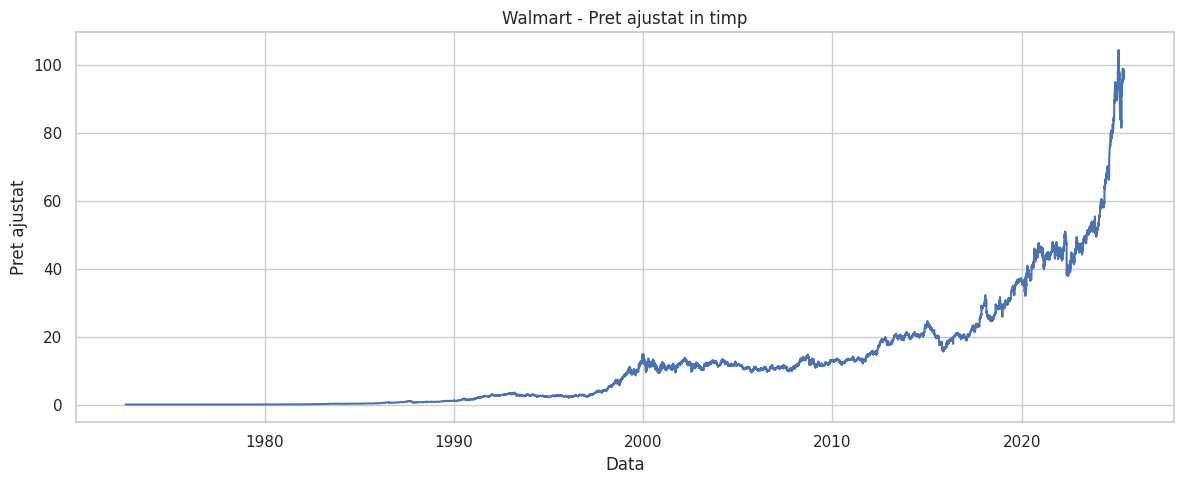

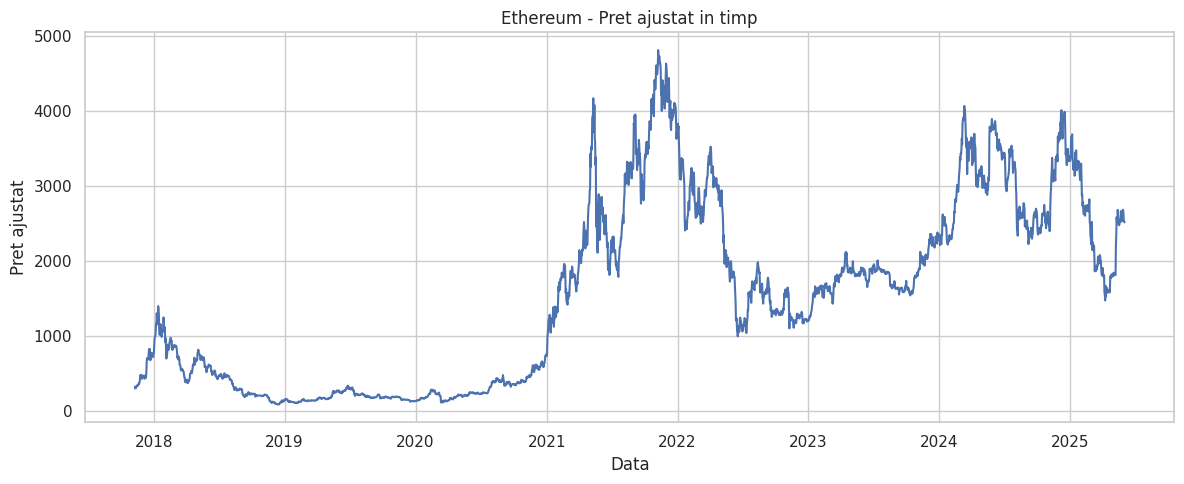

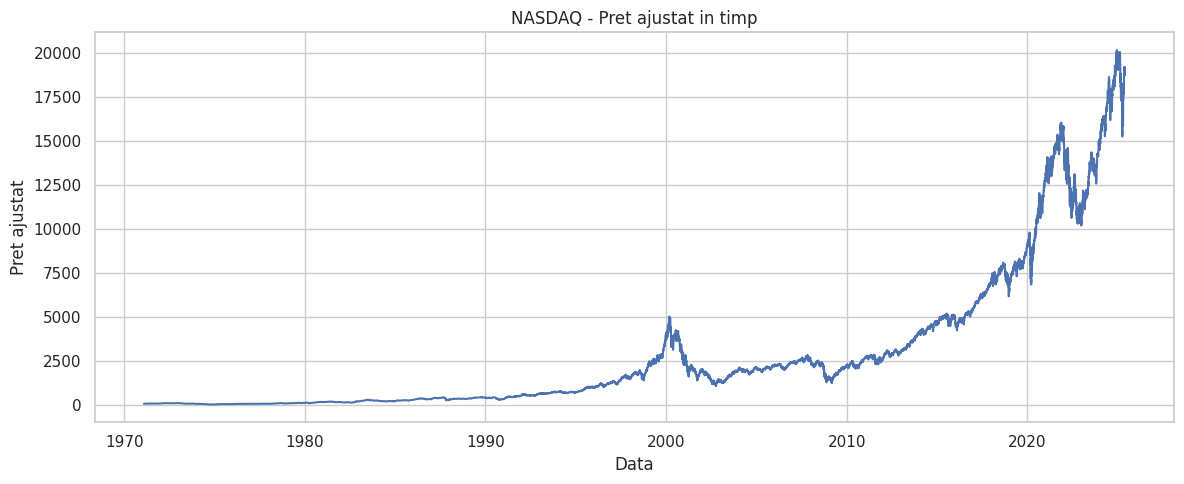

In [8]:
# 1. Line chart cu preturile ajustate
plt.figure(figsize=(12, 5))
plt.plot(WMT_df['Adj Close'])
plt.title('Walmart - Pret ajustat in timp')
plt.xlabel('Data')
plt.ylabel('Pret ajustat')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(ETH_df['Adj Close'])
plt.title('Ethereum - Pret ajustat in timp')
plt.xlabel('Data')
plt.ylabel('Pret ajustat')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(IXIC_df['Adj Close'])
plt.title('NASDAQ - Pret ajustat in timp')
plt.xlabel('Data')
plt.ylabel('Pret ajustat')
plt.tight_layout()
plt.show()

In [10]:
# 2. Calculul randamentelor logaritmice
WMT_log_returns = np.log(WMT_df['Adj Close'] / WMT_df['Adj Close'].shift(1)).dropna()
ETH_log_returns = np.log(ETH_df['Adj Close'] / ETH_df['Adj Close'].shift(1)).dropna()
IXIC_log_returns = np.log(IXIC_df['Adj Close'] / IXIC_df['Adj Close'].shift(1)).dropna()

# 3. Statistici descriptive
WMT_stats = {
    'Mean': WMT_log_returns.mean(),
    'Standard Deviation': WMT_log_returns.std(),
    'Skewness': skew(WMT_log_returns),
    'Kurtosis': kurtosis(WMT_log_returns)
}
WMT_stats_df = pd.DataFrame(WMT_stats)

ETH_stats = {
    'Mean': ETH_log_returns.mean(),
    'Standard Deviation': ETH_log_returns.std(),
    'Skewness': skew(ETH_log_returns),
    'Kurtosis': kurtosis(ETH_log_returns)
}
ETH_stats_df = pd.DataFrame(ETH_stats)

IXIC_stats = {
    'Mean': IXIC_log_returns.mean(),
    'Standard Deviation': IXIC_log_returns.std(),
    'Skewness': skew(IXIC_log_returns),
    'Kurtosis': kurtosis(IXIC_log_returns)
}
IXIC_stats_df = pd.DataFrame(IXIC_stats)

complete_stats_df = pd.concat([WMT_stats_df, ETH_stats_df, IXIC_stats_df])

display(complete_stats_df)

,Mean,Standard Deviation,Skewness,Kurtosis
Ticker,,,,
WMT,0.000681,0.018383,-0.007162,6.311053
ETH-USD,0.000746,0.046140,-0.812653,10.739075
^IXIC,0.000384,0.012734,-0.328220,9.638531


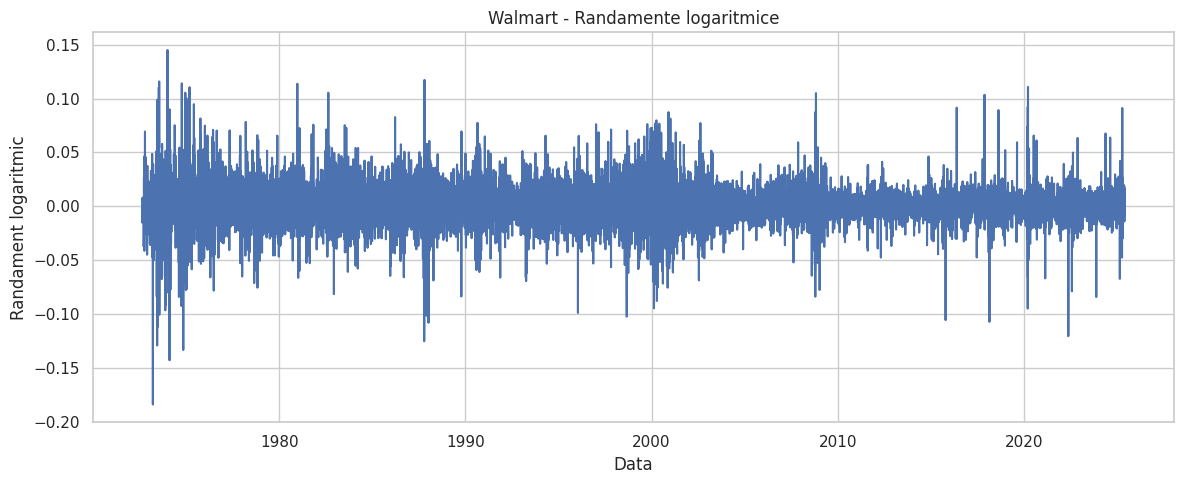

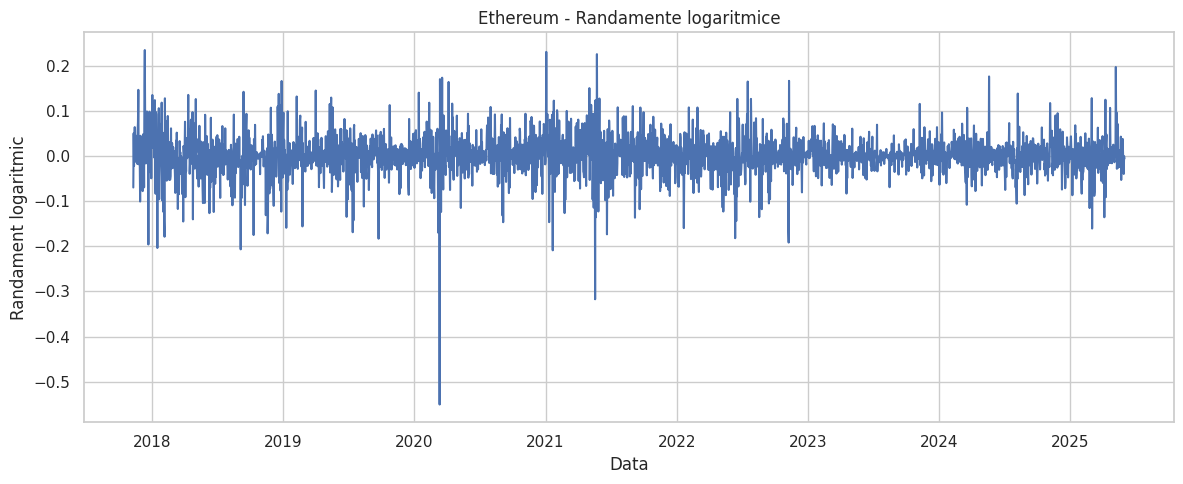

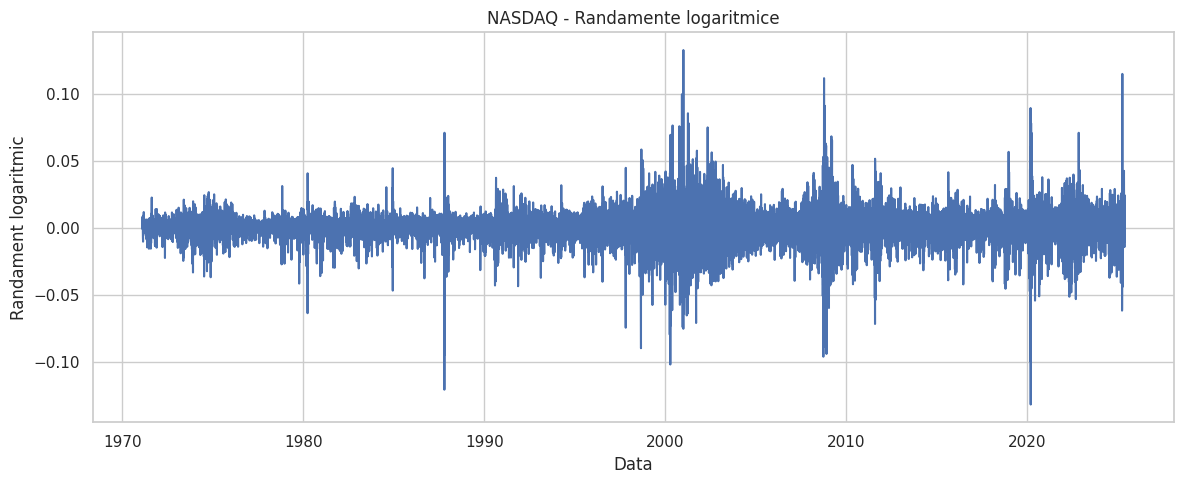

In [11]:
# 4. Line chart cu randamentele logaritmice
plt.figure(figsize=(12, 5))
plt.plot(WMT_log_returns)
plt.title('Walmart - Randamente logaritmice')
plt.xlabel('Data')
plt.ylabel('Randament logaritmic')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(ETH_log_returns)
plt.title('Ethereum - Randamente logaritmice')
plt.xlabel('Data')
plt.ylabel('Randament logaritmic')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(IXIC_log_returns)
plt.title('NASDAQ - Randamente logaritmice')
plt.xlabel('Data')
plt.ylabel('Randament logaritmic')
plt.tight_layout()
plt.show()

In [46]:
# 5. Tabel cu cuantilele randamentelor

WMT_quantiles = WMT_log_returns.quantile([0.00, 0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1.00])
ETH_quantiles = ETH_log_returns.quantile([0.00, 0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1.00])
IXIC_quantiles = IXIC_log_returns.quantile([0.00, 0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1.00])
quantiles = WMT_quantiles.merge(ETH_quantiles, how='inner', left_index=True, right_index=True).merge(IXIC_quantiles, how='inner', left_index=True, right_index=True)

print("Cuantilele randamentelor logaritmice:\n")
display(quantiles)
print('\n')

# 6. Filtrarea randamentelor extreme

def extreme_returns_table(log_returns_df):

    # Resetam indexul si redenumim coloana ca 'Return'
    df = log_returns_df.reset_index()
    df.columns = ['Date', 'Return']

    # Grupare dupa valoare si agregare pentru frecventa
    grouped = df.groupby('Return').agg({
        'Date': 'min',
        'Return': 'count'
    })
    grouped.columns = ['Date', 'Obs']
    grouped.reset_index(inplace=True)

    # Cele mai mici 10
    lowest = grouped.sort_values(by='Return').head(10)
    lowest = lowest[['Return', 'Date', 'Obs']].rename(columns={'Return': 'Value'})

    # Cele mai mari 10
    highest = grouped.sort_values(by='Return', ascending=False).head(10)
    highest = highest[['Return', 'Date', 'Obs']].rename(columns={'Return': 'Value'})

    # Tabel final
    extreme_table = pd.concat([lowest.reset_index(drop=True),
                               highest.reset_index(drop=True)], axis=1)

    extreme_table.columns = [
        'Value (Lowest)', 'Date (Lowest)', 'Obs (Lowest)',
        'Value (Highest)', 'Date (Highest)', 'Obs (Highest)'
    ]

    return extreme_table


WMT_extreme_table = extreme_returns_table(WMT_log_returns)
print("Tabel cu randamente extreme pentru - Walmart")
display(WMT_extreme_table)
print('\n')

ETH_extreme_table = extreme_returns_table(ETH_log_returns)
print("Tabel cu randamente extreme pentru - Ethereum")
display(ETH_extreme_table)
print('\n')

IXIC_extreme_table = extreme_returns_table(IXIC_log_returns)
print("Tabel cu randamente extreme pentru - NASDAQ")
display(IXIC_extreme_table)



Cuantilele randamentelor logaritmice:



Ticker,WMT,ETH-USD,^IXIC
0.00,-0.184225,-0.550732,-0.131492
0.01,-0.049762,-0.136196,-0.038026
0.05,-0.026892,-0.071437,-0.020422
0.10,-0.018692,-0.047011,-0.013068
0.25,-0.008335,-0.018954,-0.004599
0.50,0.000000,0.000717,0.001061
0.75,0.009282,0.021796,0.006241
0.90,0.020412,0.049900,0.012555
0.95,0.029103,0.071031,0.018196
0.99,0.053503,0.126294,0.033952




Tabel cu randamente extreme pentru - Walmart


,Value (Lowest),Date (Lowest),Obs (Lowest),Value (Highest),Date (Highest),Obs (Highest)
0,-0.184225,1973-03-22,1,0.144993,1974-01-03,1
1,-0.143122,1974-02-12,1,0.117270,1987-10-21,1
2,-0.133587,1974-11-08,1,0.115833,1973-07-24,1
3,-0.129414,1973-06-14,1,0.114086,1974-10-10,1
4,-0.125417,1987-10-16,1,0.113722,1980-12-23,1
5,-0.120765,2022-05-17,1,0.110723,2020-03-17,1
6,-0.112086,1973-06-26,1,0.110438,1975-03-11,1
7,-0.108342,1988-01-08,1,0.110313,1973-07-16,1
8,-0.107398,2018-02-20,1,0.106801,1975-03-10,1
9,-0.105810,2015-10-14,1,0.105361,1974-12-18,1




Tabel cu randamente extreme pentru - Ethereum


,Value (Lowest),Date (Lowest),Obs (Lowest),Value (Highest),Date (Highest),Obs (Highest)
0,-0.550732,2020-03-12,1,0.234741,2017-12-12,1
1,-0.317459,2021-05-19,1,0.230695,2021-01-03,1
2,-0.209000,2021-01-21,1,0.225649,2021-05-24,1
3,-0.206860,2018-09-05,1,0.197200,2025-05-08,1
4,-0.203831,2018-01-16,1,0.176238,2024-05-20,1
5,-0.196095,2017-12-22,1,0.173452,2020-03-19,1
6,-0.191844,2022-11-09,1,0.170272,2020-03-13,1
7,-0.183255,2019-09-24,1,0.166488,2022-11-10,1
8,-0.182126,2022-06-13,1,0.166150,2018-12-28,1
9,-0.178902,2018-02-05,1,0.164962,2022-07-18,1




Tabel cu randamente extreme pentru - NASDAQ


,Value (Lowest),Date (Lowest),Obs (Lowest),Value (Highest),Date (Highest),Obs (Highest)
0,-0.131492,2020-03-16,1,0.132546,2001-01-03,1
1,-0.120432,1987-10-19,1,0.114784,2025-04-09,1
2,-0.101684,2000-04-14,1,0.111594,2008-10-13,1
3,-0.099099,2020-03-12,1,0.099636,2000-12-05,1
4,-0.095877,2008-09-29,1,0.091063,2008-10-28,1
5,-0.094428,1987-10-26,1,0.089347,2020-03-13,1
6,-0.094256,1987-10-20,1,0.085454,2001-04-05,1
7,-0.093809,2008-12-01,1,0.078098,2001-04-18,1
8,-0.089536,1998-08-31,1,0.078085,2020-03-24,1
9,-0.088502,2008-10-15,1,0.076372,2000-05-30,1


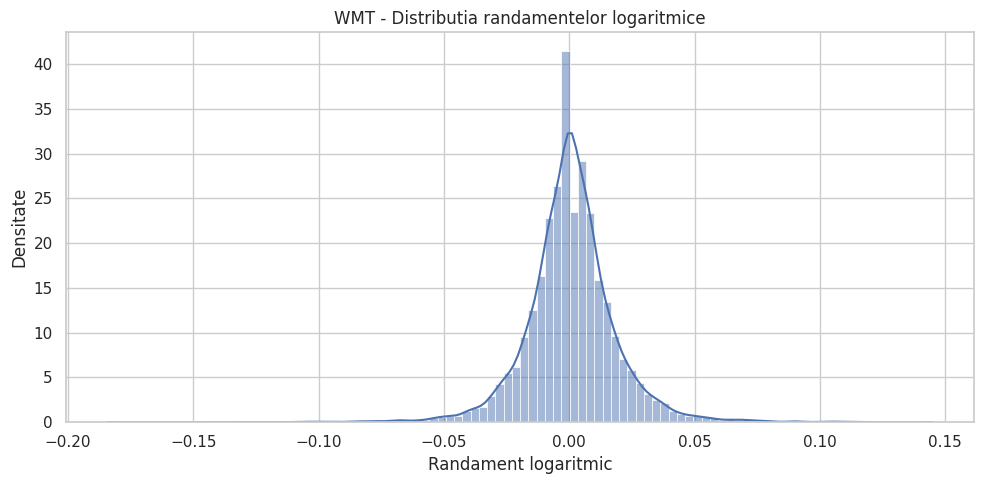


WMT - Test Kolmogorov-Smirnov pentru normalitate:
Statistica KS = 0.0749, p-valoare = 0.0000


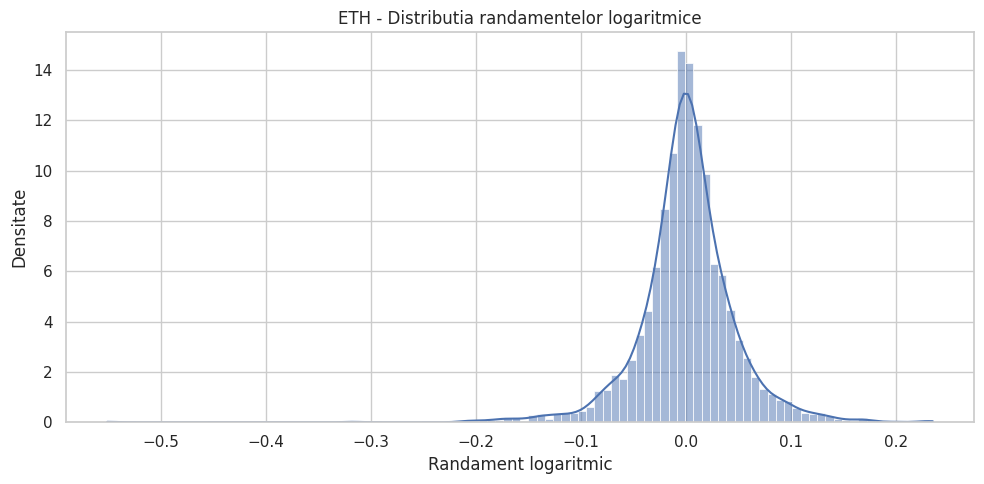


ETH - Test Kolmogorov-Smirnov pentru normalitate:
Statistica KS = 0.0879, p-valoare = 0.0000


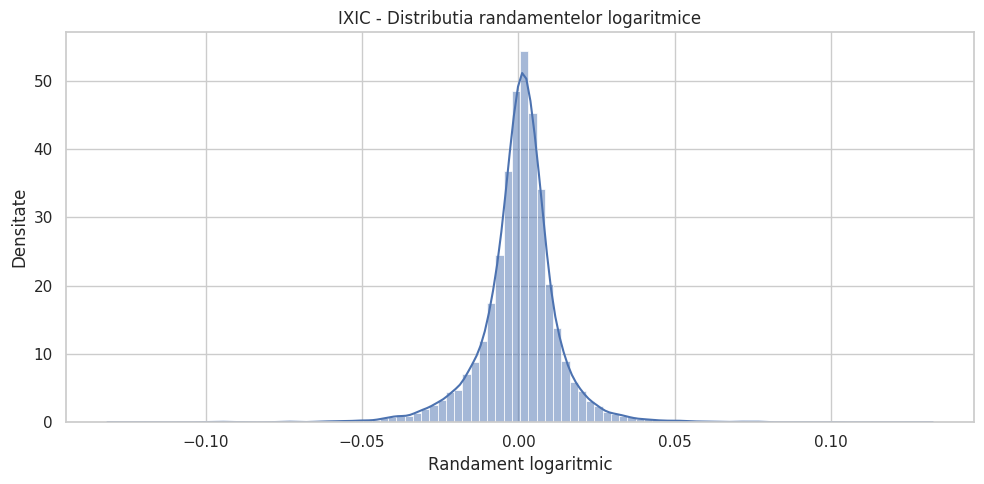


IXIC - Test Kolmogorov-Smirnov pentru normalitate:
Statistica KS = 0.0981, p-valoare = 0.0000


In [50]:
#7. Histograma randamentelor si aplicarea testului Kolmogorov-Smirnov pentru normalitate

def plot_histogram_and_ks_test(log_returns_df, ticker="Asset"):

    # Extragem seria de randamente (presupunem ca e o singura coloana)
    serie = log_returns_df.iloc[:, 0]

    # Histograma + KDE
    plt.figure(figsize=(10, 5))
    sns.histplot(serie, bins=100, kde=True, stat="density")
    plt.title(f'{ticker} - Distributia randamentelor logaritmice')
    plt.xlabel('Randament logaritmic')
    plt.ylabel('Densitate')
    plt.tight_layout()
    plt.show()

    # Standardizare
    standardized = (serie - serie.mean()) / serie.std()

    # Test KS
    ks_stat, ks_p = kstest(standardized, 'norm')
    ks_stat = float(ks_stat)
    ks_p = float(ks_p)

    print(f"\n{ticker} - Test Kolmogorov-Smirnov pentru normalitate:")
    print(f"Statistica KS = {ks_stat:.4f}, p-valoare = {ks_p:.4f}")


plot_histogram_and_ks_test(WMT_log_returns, 'WMT')
plot_histogram_and_ks_test(ETH_log_returns, 'ETH')
plot_histogram_and_ks_test(IXIC_log_returns, 'IXIC')


Pareto estimat pentru WMT - Coada stanga (quantile=0.05):
b = 4.3886
loc = -0.0230
scale = 0.0499

Testul Kolmogorov-Smirnov pentru potrivirea intre distributia Pareto si randamentele extreme negative
KS-stat = 0.0281, p-valoare = 0.6583


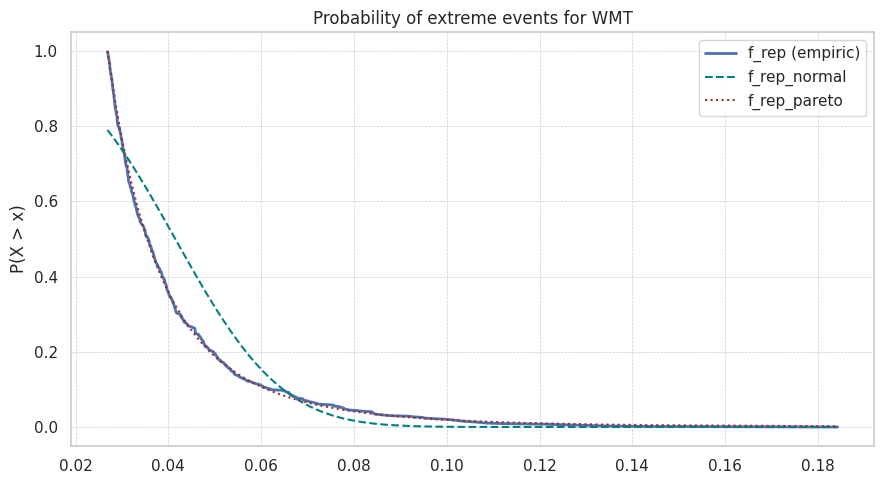


Pareto estimat pentru ETH - Coada stanga (quantile=0.05):
b = 5.0295
loc = -0.0929
scale = 0.1644

Testul Kolmogorov-Smirnov pentru potrivirea intre distributia Pareto si randamentele extreme negative
KS-stat = 0.0575, p-valoare = 0.7290


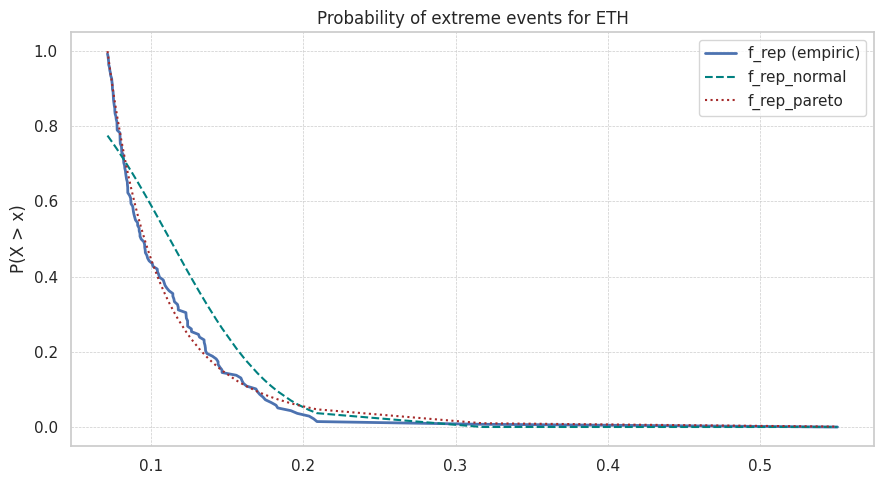


Pareto estimat pentru IXIC - Coada stanga (quantile=0.05):
b = 6.8243
loc = -0.0455
scale = 0.0660

Testul Kolmogorov-Smirnov pentru potrivirea intre distributia Pareto si randamentele extreme negative
KS-stat = 0.0255, p-valoare = 0.7533


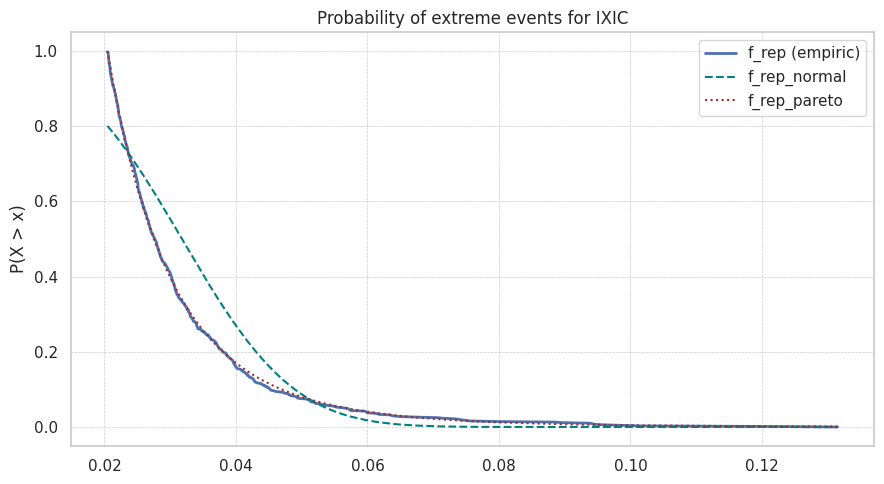

In [111]:
from scipy.stats import pareto, norm

def plot_ccdf_comparison_left_tail(log_returns, ticker, quantile=0.05):

    # Extractie serie daca e DataFrame
    if isinstance(log_returns, pd.DataFrame):
        serie = log_returns.iloc[:, 0]
    else:
        serie = log_returns

    # Selectam coada stanga (pierderi extreme)
    threshold = serie.quantile(quantile)
    extreme_losses = serie[serie < threshold].dropna()
    extreme_losses = extreme_losses[np.isfinite(extreme_losses)]

    # Shiftam la pozitive pentru Pareto & comparatie
    shifted_data = -extreme_losses
    shifted_data = np.sort(shifted_data)
    n = len(shifted_data)

    # Empirical CCDF
    cdf_empiric = np.arange(1, n + 1) / n
    ccdf_empiric = 1 - cdf_empiric

    # Normal CCDF
    mu, sigma = shifted_data.mean(), shifted_data.std()
    ccdf_normal = 1 - norm.cdf(shifted_data, loc=mu, scale=sigma)

    # Pareto CCDF
    b, loc, scale = pareto.fit(shifted_data)
    ccdf_pareto = 1 - pareto.cdf(shifted_data, b, loc=loc, scale=scale)
    print(f"\nPareto estimat pentru {ticker} - Coada stanga (quantile={quantile}):")
    print(f"b = {b:.4f}")
    print(f"loc = {loc:.4f}")
    print(f"scale = {scale:.4f}")

    D, p_value = kstest(shifted_data, 'pareto', args=(b, loc, scale))
    print(f"\nTestul Kolmogorov-Smirnov pentru potrivirea intre distributia Pareto si randamentele extreme negative")
    print(f"KS-stat = {D:.4f}, p-valoare = {p_value:.4f}")

    # Plot
    plt.figure(figsize=(9, 5))
    plt.plot(shifted_data, ccdf_empiric, label='f_rep (empiric)', linewidth=2)
    plt.plot(shifted_data, ccdf_normal, label='f_rep_normal', color='teal', linestyle='--')
    plt.plot(shifted_data, ccdf_pareto, label='f_rep_pareto', color='brown', linestyle=':')

    plt.ylabel('P(X > x)')
    plt.title(f'Probability of extreme events for {ticker}')
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Apelam pentru toate cele 3 active
plot_ccdf_comparison_left_tail(WMT_log_returns, 'WMT')
plot_ccdf_comparison_left_tail(ETH_log_returns, 'ETH')
plot_ccdf_comparison_left_tail(IXIC_log_returns, 'IXIC')

In [112]:
from statsmodels.stats.diagnostic import acorr_ljungbox, acorr_breusch_godfrey
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.sandbox.stats.runs import runstest_1samp

# Teste de autocorelare
def autocorrelation_tests(log_returns, ticker):
    print(f'\n______ {ticker} ______')

    # Test Ljung-Box
    lb_test = acorr_ljungbox(log_returns, lags=[10], return_df=True)
    print(f'Ljung-Box test (lag=10):\n{lb_test}')

    # Test Breusch-Godfrey (pe AR(1))
    model = AutoReg(log_returns, lags=1).fit()
    bg_test = acorr_breusch_godfrey(model, nlags=10)
    print(f'Breusch-Godfrey test (lag=10):\nChi2 stat: {bg_test[0]:.4f}, p-value: {bg_test[1]:.4f}')

    # Test Wald-Wolfowitz
    # runstest_1samp are nevoie de date binare, de obicei verificăm semnul
    signs = np.sign(log_returns)
    runs_test_stat, runs_p_value = runstest_1samp(signs)
    print(f'Wald-Wolfowitz test: stat: {runs_test_stat:.4f}, p-value: {runs_p_value:.4f}')


autocorrelation_tests(WMT_log_returns, "WMT")
autocorrelation_tests(ETH_log_returns, "ETH")
autocorrelation_tests(IXIC_log_returns, "IXIC")


______ WMT ______
Ljung-Box test (lag=10):
      lb_stat     lb_pvalue
10  74.991905  4.775084e-12
Breusch-Godfrey test (lag=10):
Chi2 stat: 41.9407, p-value: 0.0000
Wald-Wolfowitz test: stat: -0.8156, p-value: 0.4147

______ ETH ______
Ljung-Box test (lag=10):
      lb_stat  lb_pvalue
10  30.702595   0.000657
Breusch-Godfrey test (lag=10):
Chi2 stat: 25.7545, p-value: 0.0041
Wald-Wolfowitz test: stat: 4.0422, p-value: 0.0001

______ IXIC ______
Ljung-Box test (lag=10):
      lb_stat  lb_pvalue
10  37.263256   0.000051
Breusch-Godfrey test (lag=10):
Chi2 stat: 36.0829, p-value: 0.0001
Wald-Wolfowitz test: stat: -10.7941, p-value: 0.0000


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [113]:
def get_log_returns(ticker):
    df = yf.download(ticker, progress=False, auto_adjust=False)
    return np.log(df['Adj Close'] / df['Adj Close'].shift(1)).dropna()

def autocorrelation_tests(log_returns):
    # Ljung-Box
    lb_test = acorr_ljungbox(log_returns, lags=[10], return_df=True)
    lb_pvalue = lb_test['lb_pvalue'].iloc[0]

    # Breusch-Godfrey pe AR(1)
    model = AutoReg(log_returns, lags=1).fit()
    bg_test = acorr_breusch_godfrey(model, nlags=10)
    bg_pvalue = bg_test[1]

    # Wald-Wolfowitz (semnele)
    signs = np.sign(log_returns)
    _, ww_pvalue = runstest_1samp(signs)

    return lb_pvalue, bg_pvalue, ww_pvalue

# Pregătim tabelul de rezultate
results = pd.DataFrame(index=['Ljung-Box (p-value)', 'Breusch-Godfrey (p-value)', 'Wald-Wolfowitz (p-value)'],
                        columns=['WMT', 'ETH-USD', '^IXIC'])

# Iterăm pe cele 3 active și completăm tabelul
for ticker in ['WMT', 'ETH-USD', '^IXIC']:
    returns = get_log_returns(ticker)
    lb_p, bg_p, ww_p = autocorrelation_tests(returns)
    results[ticker] = [lb_p, bg_p, ww_p]

# Afișăm tabelul final
print(results)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                    WMT   ETH-USD         ^IXIC
Ljung-Box (p-value)        4.774633e-12  0.000657  5.095511e-05
Breusch-Godfrey (p-value)  7.683751e-06  0.004085  8.145778e-05
Wald-Wolfowitz (p-value)   4.147341e-01  0.000053  3.670679e-27


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:4006: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


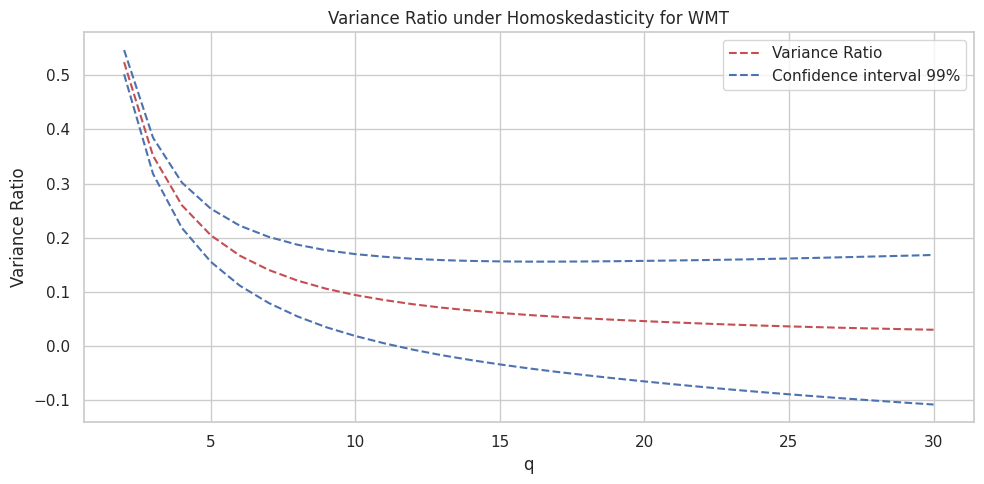

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:4006: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


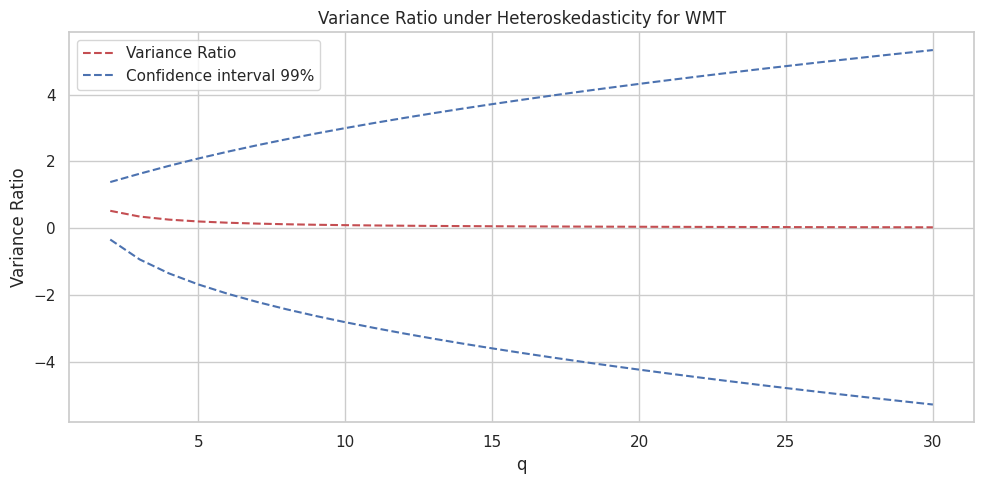

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:4006: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


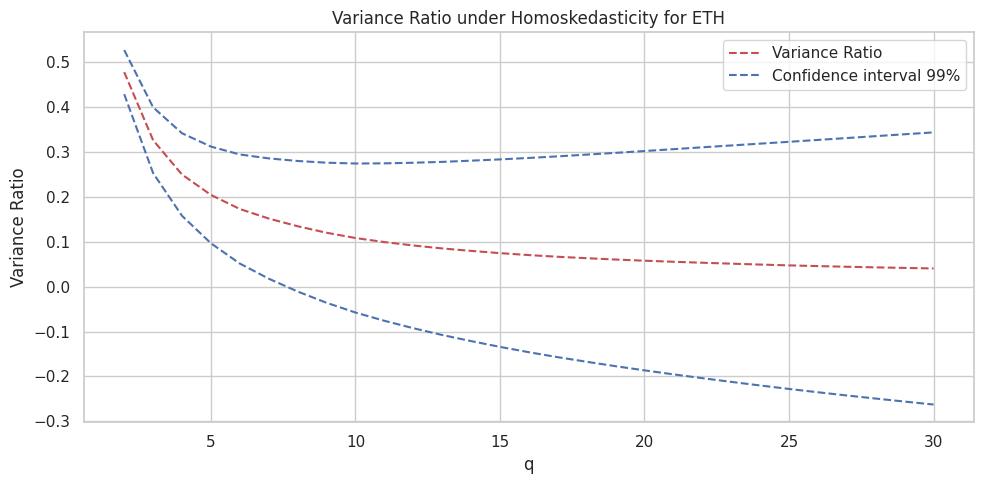

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:4006: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


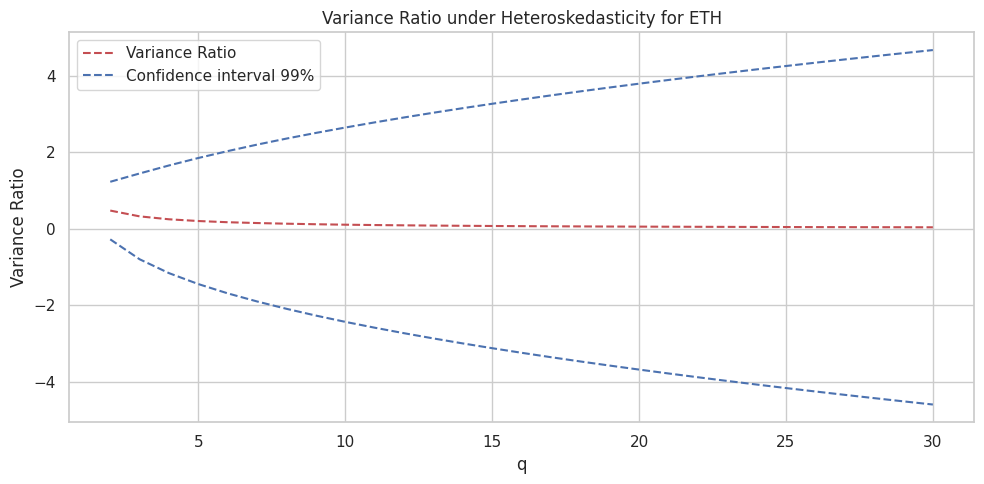

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:4006: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


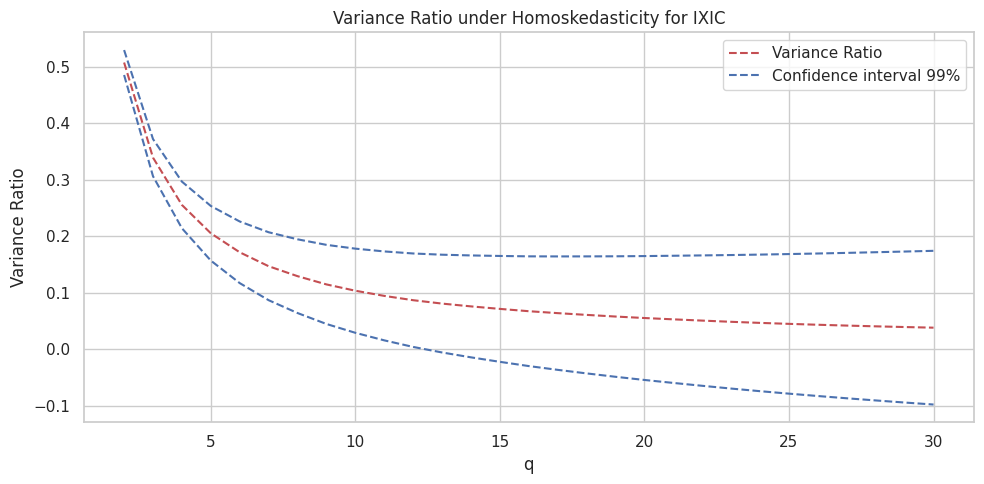

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:4006: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


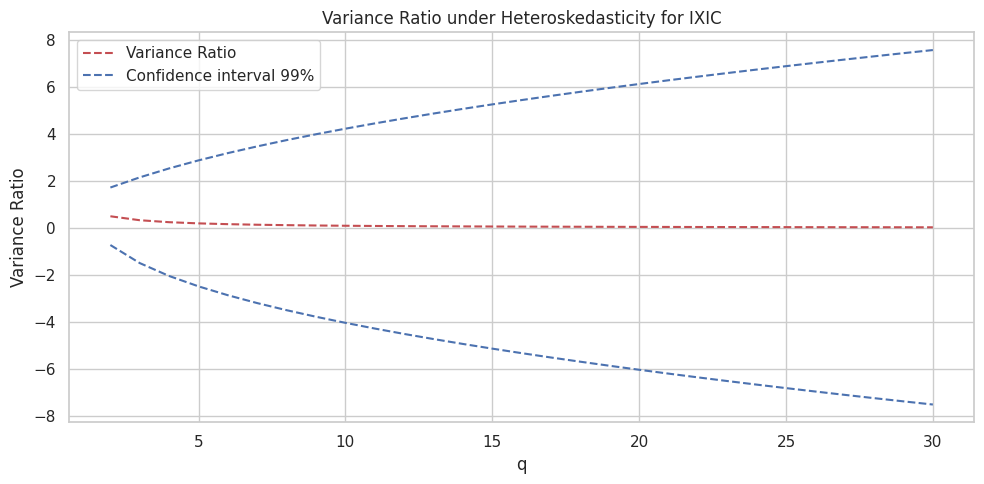

In [122]:
def variance_ratio_homoskedasticity(log_returns, ticker, max_lag=30):
    log_returns = log_returns.dropna()
    n = len(log_returns)
    var_1 = np.var(log_returns, ddof=1)
    lags = np.arange(2, max_lag + 1)
    vr_values = []
    ci_upper = []
    ci_lower = []

    for q in lags:
        m = n - q + 1
        summed = np.array([np.sum(log_returns[i:i+q]) for i in range(m)])
        var_q = np.var(summed / q, ddof=1)
        vr = var_q / var_1
        vr_values.append(vr)

        se = np.sqrt(2 * (2 * q - 1) * (q - 1) / (3 * q * n))
        ci_upper.append(vr + 2.58 * se)
        ci_lower.append(vr - 2.58 * se)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(lags, vr_values, 'r--', label='Variance Ratio')
    plt.plot(lags, ci_upper, 'b--', label='Confidence interval 99%')
    plt.plot(lags, ci_lower, 'b--')
    plt.xlabel('q')
    plt.ylabel('Variance Ratio')
    plt.title(f'Variance Ratio under Homoskedasticity for {ticker}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def variance_ratio_heteroskedasticity(log_returns, ticker, max_lag=30):
    log_returns = log_returns.dropna()
    n = len(log_returns)
    mu = np.mean(log_returns)
    var_1 = np.var(log_returns, ddof=1)
    lags = np.arange(2, max_lag + 1)
    vr_values = []
    ci_upper = []
    ci_lower = []

    for q in lags:
        m = n - q + 1
        summed = np.array([np.sum(log_returns[i:i+q]) for i in range(m)])
        var_q = np.var(summed / q, ddof=1)
        vr = var_q / var_1
        vr_values.append(vr)

        s = 0
        for j in range(1, q):
            gamma = np.sum((log_returns[j:] - mu) * (log_returns[:-j] - mu)) / n
            s += ((q - j) / q)**2 * gamma
        se = np.sqrt((s * 2) / (n * var_1**2))
        ci_upper.append(vr + 2.58 * se)
        ci_lower.append(vr - 2.58 * se)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(lags, vr_values, 'r--', label='Variance Ratio')
    plt.plot(lags, ci_upper, 'b--', label='Confidence interval 99%')
    plt.plot(lags, ci_lower, 'b--')
    plt.xlabel('q')
    plt.ylabel('Variance Ratio')
    plt.title(f'Variance Ratio under Heteroskedasticity for {ticker}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


variance_ratio_homoskedasticity(WMT_log_returns, 'WMT')
variance_ratio_heteroskedasticity(WMT_log_returns, 'WMT')

variance_ratio_homoskedasticity(ETH_log_returns, 'ETH')
variance_ratio_heteroskedasticity(ETH_log_returns, 'ETH')

variance_ratio_homoskedasticity(IXIC_log_returns, 'IXIC')
variance_ratio_heteroskedasticity(IXIC_log_returns, 'IXIC')

In [125]:
# Instalare pachetul 'arch'
!pip install arch

/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003379. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(



_____ WMT _____
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    WMT   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                35964.2
Distribution:                  Normal   AIC:                          -71920.5
Method:            Maximum Likelihood   BIC:                          -71890.5
                                        No. Observations:                13300
Date:                Sun, Jun 01 2025   Df Residuals:                    13299
Time:                        20:53:13   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         6.8366e-04  2.855e-05     23.9

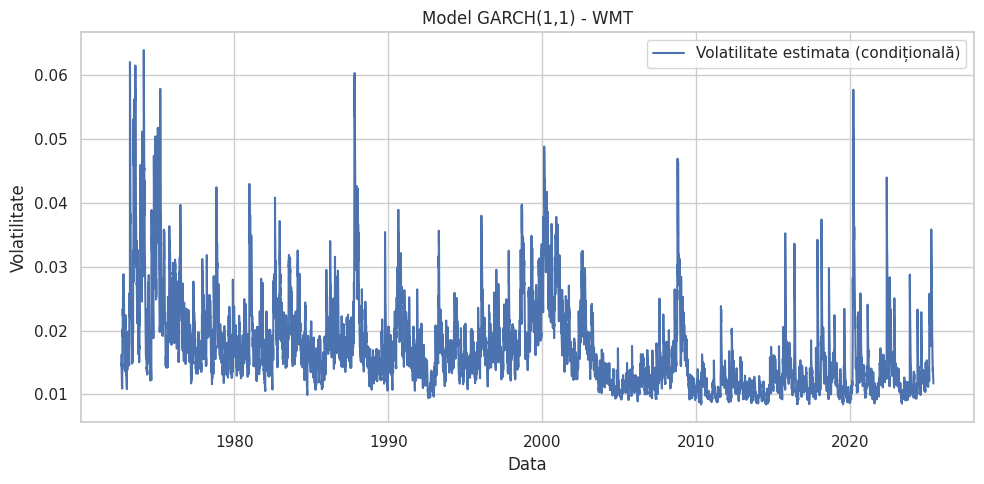

/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.002128. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(



_____ ETH _____
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                ETH-USD   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                4758.25
Distribution:                  Normal   AIC:                          -9508.50
Method:            Maximum Likelihood   BIC:                          -9484.81
                                        No. Observations:                 2761
Date:                Sun, Jun 01 2025   Df Residuals:                     2760
Time:                        20:53:13   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         8.2927e-04  7.325e-04      

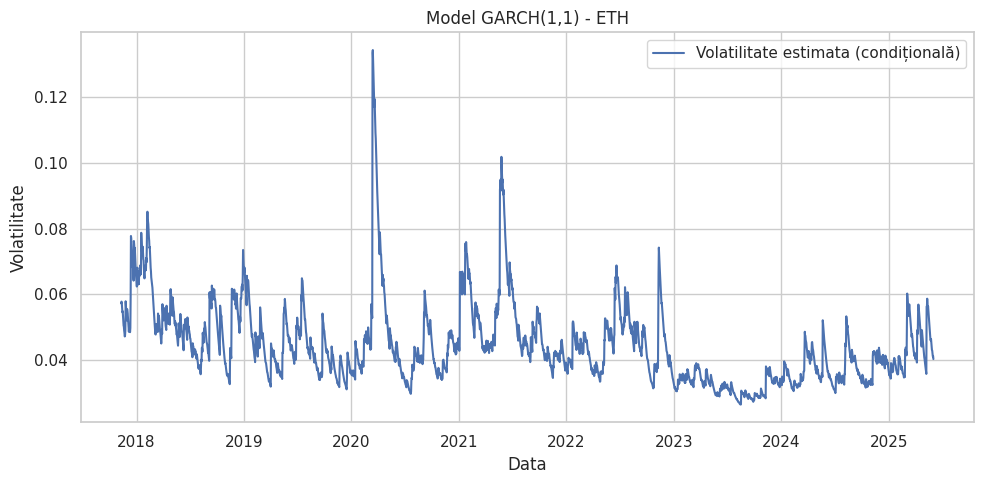

/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001621. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(



_____ IXIC _____
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  ^IXIC   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                43929.6
Distribution:                  Normal   AIC:                          -87851.2
Method:            Maximum Likelihood   BIC:                          -87821.1
                                        No. Observations:                13694
Date:                Sun, Jun 01 2025   Df Residuals:                    13693
Time:                        20:53:14   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         3.8360e-04  6.233e-05      6.

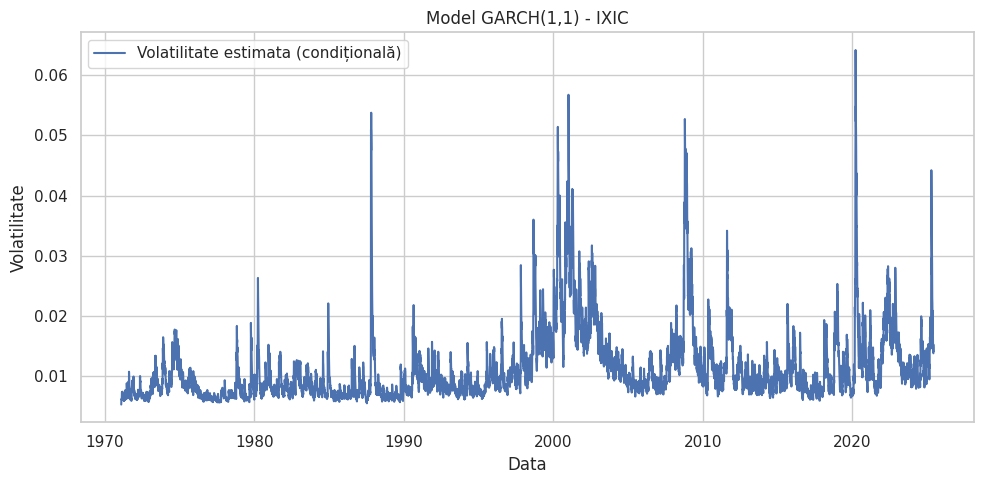

In [126]:
# Importam bibliotecile necesare
from arch import arch_model

# Functie pentru model GARCH si graficul de volatilitate
def fit_garch_model(log_returns, ticker):
    am = arch_model(log_returns, vol='Garch', p=1, q=1)
    res = am.fit(disp='off')

    print(f'\n_____ {ticker} _____')
    print(res.summary())

    # Grafic volatilitate
    plt.figure(figsize=(10, 5))
    plt.plot(res.conditional_volatility, label='Volatilitate estimata (condițională)')
    plt.xlabel('Data')
    plt.ylabel('Volatilitate')
    plt.title(f'Model GARCH(1,1) - {ticker}')
    plt.legend()
    plt.tight_layout()
    plt.show()

fit_garch_model(WMT_log_returns, 'WMT')
fit_garch_model(ETH_log_returns, 'ETH')
fit_garch_model(IXIC_log_returns, 'IXIC')

In [127]:
# Instalare pachetul "hurst"
!pip install hurst

In [129]:
# Importam bibliotecile necesare
from hurst import compute_Hc

# Functie pentru calcul exponent Hurst (cu corectie de zero-division)
def calculate_hurst(log_returns, ticker):
    # Cum hurst vrea "preturi" pozitive, cream o serie de preturi "simulate"
    price_series = log_returns.cumsum() + 100  # asiguram valori pozitive, shiftam cu 100
    H, c, data = compute_Hc(price_series, kind='price', simplified=True)
    print(f'\n______ {ticker} ______')
    print(f'Exponentul Hurst: {H:.4f}')
    if H < 0.5:
        print('➡️ Trend anti-persistent (mean-reverting)')
    elif H > 0.5:
        print('➡️ Trend persistent (long memory)')
    else:
        print('➡️ Proces random (Brownian motion)')


calculate_hurst(WMT_log_returns, 'WMT')
calculate_hurst(ETH_log_returns, 'ETH')
calculate_hurst(IXIC_log_returns, 'IXIC')


______ WMT ______
Exponentul Hurst: 0.6799
➡️ Trend persistent (long memory)

______ ETH ______
Exponentul Hurst: 0.5616
➡️ Trend persistent (long memory)

______ IXIC ______
Exponentul Hurst: 0.6292
➡️ Trend persistent (long memory)
